# EBM 1b — Adjustment over time

<a class="btn btn-primary btn-sm" href="https://dhruvbalwada.github.io/intro-climate-modeling-fall2026/labs/lab1b_adjustment.ipynb" download>Download this notebook (.ipynb)</a>

Upload it to [LEAP](https://leap.2i2c.cloud/) and open it with a Python kernel. 

**In-class activity · uses the model discussed in class**

## Learning objectives

- Distinguish an immediate change in radiation from the temperature response that follows.
- Use energy imbalances to explain how two reservoirs warm.
- Test how surface heat capacity changes adjustment without changing equilibrium.

The integration and plotting code are supplied. Your work is to state what you expect and why, run the experiments, and explain the results in the response cells. Read each question before running the cells below it. Save your notebook with plots and your own written responses. Complete all four sections in class, including the changing-flux experiments and discussion in Section 4.

This notebook runs independently of 1a and needs only NumPy and Matplotlib. Run cells in order. It uses the same model and constants as 1a.

## 1. From equilibrium to rates of change

Keep the surface black in the longwave, the atmosphere transparent to sunlight, and albedo fixed. There is still no convection, evaporation, or longwave reflection. The budgets are

$$C_s\frac{dT_s}{dt}=Q+\epsilon\sigma T_a^4-\sigma T_s^4\equiv R_s,$$
$$C_a\frac{dT_a}{dt}=\epsilon\sigma T_s^4-2\epsilon\sigma T_a^4\equiv R_a.$$

Each $R$ is a net heating flux (W m$^{-2}$); divide by its reservoir's heat capacity per area (J m$^{-2}$ K$^{-1}$) to obtain K s$^{-1}$. Thus **flux imbalance changes stored energy, which changes temperature**—the same logic as water accumulation changing bucket level.

For the combined system,

$$\mathrm{OLR}=(1-\epsilon)\sigma T_s^4+\epsilon\sigma T_a^4,\qquad N=Q-\mathrm{OLR}=R_s+R_a.$$

Positive $N$ means the planet is gaining energy. Unlike equilibrium, OLR need not equal $Q$ during adjustment.

## Before running: what do you expect?

Start from the 288 K equilibrium discussed in class (also explored in optional notebook 1a). At $t=0$, increase $\epsilon$ from its fitted value (about 0.779) to 0.82 and hold it there. **Do you expect the surface to warm or cool?** Explain your reasoning before running the model.

**Your expectation and reasoning:**

_Write here._

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 1361.0          # W m^-2
alpha = 0.30
sigma = 5.670374419e-8  # W m^-2 K^-4
Q = S0 * (1 - alpha) / 4
DAY = 86400.0       # seconds
YEAR = 365.0 * DAY  # fixed-length year for this experiment

# Illustrative effective heat capacities per unit area, not fitted to Earth.
Cs = 1.0e8          # J m^-2 K^-1
Ca = 1.0e7          # J m^-2 K^-1

# Calculate the fitted initial equilibrium discussed in class.
epsilon_old = 2 * (1 - Q / (sigma * 288.0**4))
epsilon_new = 0.82  # prescribed absorption experiment, NOT a CO2 concentration

def equilibrium(epsilon):
    """Equilibrium Ts and Ta (K); requires 0 < epsilon <= 1."""
    if not 0 < epsilon <= 1:
        raise ValueError('Atmospheric equilibrium requires 0 < epsilon <= 1')
    Ts = (Q / (sigma * (1 - epsilon / 2)))**0.25
    # Store the two temperatures in a fixed order: [surface, atmosphere].
    return np.array([Ts, Ts / 2**0.25])

def budgets(temperature, epsilon):
    """Net surface/air heating, OLR, and planetary imbalance, all W m^-2.

    temperature can be [Ts, Ta] or an array with shape (time, 2).
    """
    temperature = np.asarray(temperature)
    # The last axis holds [Ts, Ta]. The ... selects every preceding row,
    # so this works for one temperature pair or a whole time history.
    Ts, Ta = temperature[..., 0], temperature[..., 1]
    surface_emission = sigma * Ts**4
    air_emission = epsilon * sigma * Ta**4  # in EACH direction
    # Net heating = incoming minus outgoing radiation for each reservoir.
    Rs = Q + air_emission - surface_emission
    Ra = epsilon * surface_emission - 2 * air_emission
    OLR = (1 - epsilon) * surface_emission + air_emission
    N = Q - OLR
    return Rs, Ra, OLR, N

# These are temperature pairs [Ts, Ta], both in kelvin.
initial = equilibrium(epsilon_old)
# The target is an analytic endpoint for comparison, not an input to the time stepping.
target = equilibrium(epsilon_new)
print(f'Absorption step: {epsilon_old:.4f} → {epsilon_new:.4f}')
print(f'Initial equilibrium: Ts = {initial[0]:.2f} K; Ta = {initial[1]:.2f} K')

In [ ]:
# Store the old and immediate post-step budgets for later comparisons.
# Both use the same initial temperatures; only absorption changes.
before = budgets(initial, epsilon_old)
after = budgets(initial, epsilon_new)

## 2. Follow the adjustment

This is the **same forward Euler method as the bucket model in Lab 0d**, now applied to two coupled reservoirs. The supplied routine takes small forward steps:

$$T_s(t+\Delta t)=T_s(t)+\frac{R_s(t)}{C_s}\Delta t,\qquad T_a(t+\Delta t)=T_a(t)+\frac{R_a(t)}{C_a}\Delta t.$$

Both budgets use the **same old pair of temperatures** before either is updated. We use a one-day time step. Before class, this setup was checked against half-day steps; the largest temperature difference was less than 0.001 K. Forward Euler is an approximation, not an exact solution; a large step can give misleading or unstable results.

We use illustrative $C_s$ and $C_a$ to explore the roles of heat storage, without choosing a particular ocean depth. **The simulated times in years depend on these choices and are not a prediction of Earth's warming timeline.** The absorption step occurs before the first update.

In [ ]:
def integrate(initial_temperature, epsilon, Cs, Ca, years=60, dt_days=1.0):
    """Follow both temperatures after a step to a constant epsilon.

    initial_temperature is [Ts, Ta] in kelvin.
    Returns time in seconds and a temperature array with one row per time:
        temperature[n, 0] is Ts at time[n];
        temperature[n, 1] is Ta at time[n].
    """
    if Cs <= 0 or Ca <= 0 or years <= 0 or dt_days <= 0:
        raise ValueError('Heat capacities, duration, and time step must be positive')
    if not 0 <= epsilon <= 1:
        raise ValueError('epsilon must lie between 0 and 1')
    initial_temperature = np.asarray(initial_temperature, dtype=float)
    if initial_temperature.shape != (2,) or not np.all(np.isfinite(initial_temperature)):
        raise ValueError('Provide two finite initial temperatures in kelvin')
    if np.any(initial_temperature <= 0):
        raise ValueError('Initial temperatures must be positive kelvin')
    # Convert the requested duration and step to seconds. Round the number
    # of steps up so the actual step is no larger than dt_days.
    nsteps = int(np.ceil(years * YEAR / (dt_days * DAY)))
    time = np.linspace(0, years * YEAR, nsteps + 1)
    dt = time[1] - time[0]
    # Reserve a table for the full temperature history: one row for each
    # saved time, and two columns for Ts and Ta. The extra row is t=0.
    # np.empty reserves space; each row must be filled before we use it.
    temperature = np.empty((nsteps + 1, 2))
    temperature[0] = initial_temperature
    for n in range(nsteps):
        # temperature[n] is the current pair [Ts, Ta]. Calculate BOTH
        # budgets from this same pair; the underscores discard OLR and N.
        Rs, Ra, _, _ = budgets(temperature[n], epsilon)

        # [Rs/Cs, Ra/Ca] gives the two warming rates in K/s. Multiply by
        # dt to get changes in K, then store both updated temperatures
        # together in the next row (forward Euler).
        temperature[n + 1] = temperature[n] + dt * np.array([Rs / Cs, Ra / Ca])
        if not np.all(np.isfinite(temperature[n + 1])) or np.any(temperature[n + 1] <= 0):
            raise RuntimeError('Nonphysical numerical result; revisit the time step')
    return time, temperature

# Evolve the old equilibrium using the new absorption parameter.
time, temperature = integrate(initial, epsilon_new, Cs, Ca)
# Evaluate the budgets at every saved pair of temperatures for plotting.
Rs, Ra, OLR, N = budgets(temperature, epsilon_new)
print(f'After {time[-1] / YEAR:.0f} years: Ts = {temperature[-1, 0]:.3f} K; '
      f'Ta = {temperature[-1, 1]:.3f} K')
print(f'Difference from analytic equilibrium: {temperature[-1] - target} K')
print(f'Final planetary imbalance: {N[-1]:.6f} W m^-2')

In [ ]:
# temperature[:, 0] selects Ts at every saved time; [:, 1] selects Ta.
# Divide time by YEAR to display years rather than the seconds used in the model.
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True, constrained_layout=True)
axes[0].plot(time / YEAR, temperature[:, 0], label='Surface')
axes[0].axhline(target[0], color='0.4', linestyle='--', label='New equilibrium')
axes[0].set_ylabel('Surface temperature (K)')
axes[1].plot(time / YEAR, temperature[:, 1], color='tab:orange', label='Atmosphere')
axes[1].axhline(target[1], color='0.4', linestyle='--', label='New equilibrium')
axes[1].set_ylabel('Atmospheric temperature (K)')
axes[2].plot(time / YEAR, N, color='tab:green', label='Absorbed sunlight − OLR')
axes[2].axhline(0, color='0.4', linestyle='--')
axes[2].set(xlabel='Years since absorption increased', ylabel='Planetary imbalance (W m$^{-2}$)')
for ax in axes:
    ax.set_xlim(0, 15)  # Display early adjustment; integration continues to 60 years.
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
fig.suptitle('Radiation changes first; temperatures then adjust')
plt.show()

**Interpret the curves:**

1. Why is the planetary energy imbalance positive immediately after the absorption increase?
2. Why does it shrink as temperatures rise?
3. Does $N\approx0$ mean the surface has returned to its original temperature? Use the plot to support your answer.

**Your response:**

_Write here._

## 3. Give the surface more heat capacity

**Before running, what do you expect?** Multiply only $C_s$ by four. Will the initial warming rate change? Will the final surface temperature change? Explain your reasoning.

**Your expectation and reasoning:**

_Write here._

Run the comparison below. Keep $C_a$, sunlight, albedo, and the absorption change fixed so you isolate the effect of surface heat capacity.

In [ ]:
# Change only surface heat capacity. Reuse the same starting temperatures,
# absorption step, and atmospheric heat capacity.
Cs_large = 4 * Cs
time_large, temperature_large = integrate(initial, epsilon_new, Cs_large, Ca)
assert np.array_equal(time_large, time)

# Subtract the initial surface temperature to plot warming rather than
# absolute temperature. Both runs start from the same initial[0].
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.plot(time / YEAR, temperature[:, 0] - initial[0], label='Original surface heat capacity')
ax.plot(time_large / YEAR, temperature_large[:, 0] - initial[0],
        label='4 × surface heat capacity')
ax.axhline(target[0] - initial[0], color='0.4', linestyle='--', label='Same final equilibrium')
ax.set(xlim=(0, 30), xlabel='Years since absorption increased',
       ylabel='Surface warming relative to initial state (K)',
       title='More heat storage changes the adjustment, not the endpoint')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

for label, result in [('Original Cs', temperature), ('4 × Cs', temperature_large)]:
    print(f'{label}: final surface warming = {result[-1, 0] - initial[0]:.4f} K')
# after[0] is the immediate surface imbalance Rs. Dividing by Cs gives
# K/s; multiplying by DAY converts that rate to K/day.
print(f'Initial surface warming rates: {after[0] / Cs * DAY:.5f} and '
      f'{after[0] / Cs_large * DAY:.5f} K/day')

**Compare your initial expectation with the plots.** Explain in one or two sentences why two models with the same equilibrium response might warm at different rates. What changed in this experiment, and what stayed fixed?

**Your response:**

_Write here._

## 4. How the radiation budget changes during adjustment

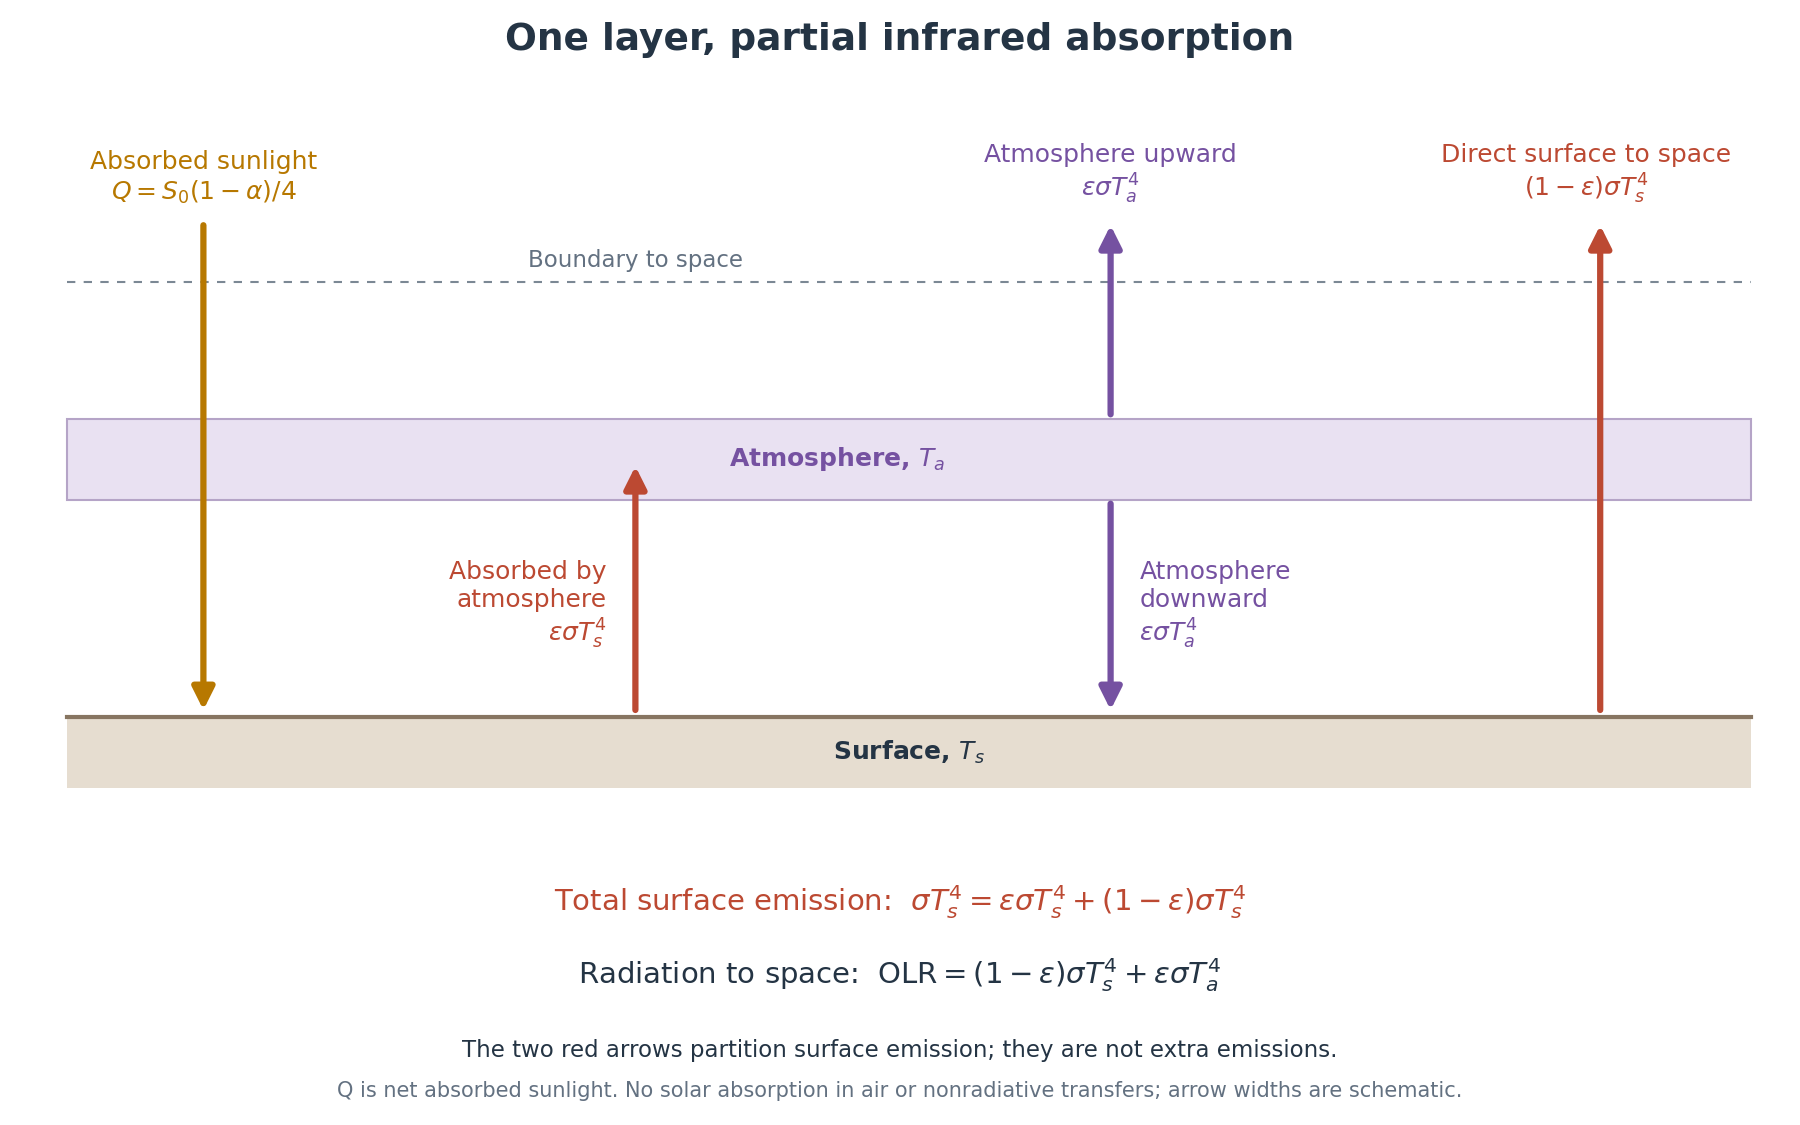

**Read the arrows:** Find each flux in the diagram. Which arrows cross the planetary boundary, and which transfer energy internally? The two red arrows add up to total surface emission; total outgoing radiation combines the directly escaping red arrow and the upward purple arrow. Arrow widths do not represent magnitudes.

**Work through this section in class. Be ready to discuss the flux table and plots together.** Plotting code is supplied. In class we balanced the individual fluxes at equilibrium, as explored in optional notebook 1a. Here we follow the same flows during adjustment.

First compare the **old equilibrium**, the **instant just after the absorption step** (unchanged temperatures), and the **new analytic equilibrium**. Values in the table are flux magnitudes in W m$^{-2}$.

The plots then show **changes from the old equilibrium**, making the jumps and slower changes visible. A negative plotted change means a smaller flux, not a reversal in the direction of that radiation. The short segment before year zero is the old equilibrium, not another numerical integration.

In [ ]:
def individual_fluxes(temp, epsilon):
    """Flux magnitudes (W m^-2), with the same definitions as notebook 1a."""
    temp = np.asarray(temp)
    # As in budgets(), columns 0 and 1 contain surface and air temperature.
    # With a time history, each expression calculates a flux at every time.
    emitted = sigma * temp[..., 0]**4
    air_each_way = epsilon * sigma * temp[..., 1]**4
    # Sunlight stays constant. Match its array shape to the other fluxes.
    solar = np.full_like(emitted, Q)
    direct = (1 - epsilon) * emitted
    return {
        'Sunlight absorbed': solar,
        'Surface emission': emitted,
        'Absorbed by atmosphere': epsilon * emitted,
        'Direct surface to space': direct,
        'Atmosphere upward': air_each_way,
        'Atmosphere downward': air_each_way,
        'Total outgoing to space': direct + air_each_way,
        'Total surface input': solar + air_each_way,
    }

# Compare three states: before the step, just after it at unchanged
# temperatures, and the new equilibrium. The final call follows all times.
old_flux = individual_fluxes(initial, epsilon_old)
instant_flux = individual_fluxes(initial, epsilon_new)
final_flux = individual_fluxes(target, epsilon_new)
flux_history = individual_fluxes(temperature, epsilon_new)

print(f'{"Flux (W m^-2)":28s} {"Old eq.":>12s} {"Just after":>12s} {"New eq.":>12s}')
for name in old_flux:
    print(f'{name:28s} {old_flux[name]:12.3f} {instant_flux[name]:12.3f} '
          f'{final_flux[name]:12.3f}')

# Check these decomposed fluxes against the budgets used by the integrator.
assert np.allclose(flux_history['Total outgoing to space'], OLR)
assert np.allclose(flux_history['Total surface input'] - flux_history['Surface emission'], Rs)
assert np.allclose(flux_history['Absorbed by atmosphere']
                   - flux_history['Atmosphere upward'] - flux_history['Atmosphere downward'], Ra)

In [ ]:
# np.r_ joins the entries into one array. Add an old-equilibrium segment
# at -1 and 0 years; time also starts at 0, representing the post-step state.
# The two entries at t=0 let the plot show an instantaneous vertical jump.
plot_years = np.r_[-1.0, 0.0, time / YEAR]
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, constrained_layout=True)

panels = [
    ('Across the planetary boundary', [
        ('Sunlight absorbed', 'tab:orange', '--'),
        ('Direct surface to space', 'tab:blue', '-'),
        ('Atmosphere upward', 'tab:red', '-'),
        ('Total outgoing to space', 'black', '-'),
    ]),
    ('Inputs and output of the surface', [
        ('Sunlight absorbed', 'tab:orange', '--'),
        ('Atmosphere downward', 'tab:red', '-'),
        ('Total surface input', 'black', '--'),
        ('Surface emission', 'tab:blue', '-'),
    ]),
]
for ax, (title, lines) in zip(axes, panels):
    for name, color, style in lines:
        # Plot anomalies relative to the old equilibrium, not absolute fluxes.
        change = flux_history[name] - old_flux[name]
        # The prepended zeros are the unchanged flux before the step.
        ax.plot(plot_years, np.r_[0.0, 0.0, change], label=name,
                color=color, linestyle=style, linewidth=2)
    ax.axvline(0, color='0.5', linestyle=':', linewidth=1)
    ax.set(title=title, ylabel='Change from old equilibrium (W m$^{-2}$)', xlim=(-1, 10))
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=9)
axes[1].set_xlabel('Years relative to the absorption increase')
fig.suptitle('Which fluxes jump, and which change as temperatures respond?')
plt.show()

### Discussion questions

Revisit the predictions from the slide before Lab 1b. Use the temperature curves, flux table, and radiation-budget plots to support your explanations.

1. **What will happen to the temperature?** Compare the initial and final surface and atmospheric temperatures. Explain how the changing surface inputs and outputs produce warming.

   **Your response:** _Write here._

2. **Do temperatures change immediately?** Distinguish a sudden change in temperature from the start of a temperature tendency. Does the surface or the atmosphere start warming first?

   **Your response:** _Write here._

3. **Which radiation fluxes change immediately?** Use the flux table to separate immediate changes from changes as temperatures respond. At the new equilibrium, which fluxes return to their original values, and which remain different?

   **Your response:** _Write here._

4. **Does the planet initially gain or lose energy?** Explain using $N=Q-\mathrm{OLR}$. How does this imbalance evolve, and does $N\approx0$ mean temperatures have returned to their initial values?

   **Your response:** _Write here._

5. **What role do the heat capacities play?** Use the two experiments to explain how increasing only $C_s$ changes the initial warming rate, the adjustment, and the final temperatures.

   **Your response:** _Write here._

## Before submitting

- Run the cells in order and check that all three figures and the flux table appear.
- Complete the expectation and response cells in your own words.
- Complete all four sections during class, including the changing-flux discussion, and save the notebook with its outputs.
- Follow the course's existing submission instructions.